# Tutorial Part 3: Local indexing

Written by Jean-Baptiste Jacob

last updated: 18/02/2026

In the previous tutorial, we saw how to sort diffraction data from complex samples featuring multiple phases and how to produce a 2D phase map with phase labels for each pixel. We introduced the new class `Pixelmap` to store and plot properties on a 2D pixel grid. At the end of Tutorial 002, we obtained a labeled phase map with a phase index assigned to each pixel, and a filtered peakfile `*_pk2d_p_flt.h5` containing a new column, `phase_id`, which assigns each peak to a phase.

Now, we want to fit a local orientation and a unit cell over each pixel, using g-vectors relocated with Fridel pair projection. This process is called **local indexing**, and is performed with the script defined in pf3dxrd.scripts.local_indexing.py. In detail, for each map position $(x_i,y_i)$, we will try to fit a lattice vector matrix  $UBI = (U \cdot B)^{-1}$, where:
- $ U $ is the crystal orientation matrix
- $ B $ the matrix of reciprocal unit cell vectors as defined in [Busy & Levy (1967)](https://scripts.iucr.org/cgi-bin/paper?s0365110x67000970).

### Load packages

In [1]:
import sys

# python environment stuff
IMAGED11_PATH = None  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = None  # the name of the git checkout folder within path. None means guess

if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    PYTHONPATH = install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)
else:
    import site
    PYTHONPATH = site.getsitepackages()[0]
    print(PYTHONPATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [3]:
# general modules
import os, glob, time
import h5py
import matplotlib.pyplot as pl
import numpy as np
from tqdm import tqdm

# ImageD11 https://github.com/FABLE-3DXRD/ImageD11
import ImageD11.sinograms.dataset
import ImageD11.columnfile
import ImageD11.parameters
import ImageD11.indexing
import ImageD11.grain
import ImageD11.sym_u

# point-fit 3dxrd module available at https://github.com/jbjacob94/pf_3dxrd.   
from pf3dxrd.pf3dxrd import utils, friedel_pairs, pixelmap, crystal_structure, peak_mapping
from pf3dxrd.scripts import local_indexing

%load_ext autoreload
%autoreload 2
%matplotlib ipympl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

We need the filtered peakfile and the grid map `pixelmap` saved in the previous step. In case of polyphasic samples, local indexing is performed separately for each phase, since each has its own symmetry and reference unit cell. Therefore, we also need to filter the peakfile by `phase_id` before indexing. Once one phase has been indexed across the entire map, the process can be repeated for the next phase, and so on.  
If multiple datasets need to be processed using the same set of indexing parameters, the script `"local_indexing.py"` can be used to run local indexing in batch mode using the same set of input parameters.


In [4]:
def load_data(dset, parfile, pname):
    # paths
    pksfile = os.path.join(data_dir, dsname+'_pk2d_p_flt.h5')
    dsfile  =  os.path.join(data_dir, dsname+'_dataset.h5')
    xmapfile =  os.path.join(data_dir, dsname+'_xmap.h5')

    ds = ImageD11.sinograms.dataset.load(dsfile)
        
    # load pixelmap
    xmap = pixelmap.load_from_hdf5(xmapfile)
    print(xmap)
    # crystal structure we want to index
    cs = xmap.phases.get(pname)
    pid = cs.phase_id
    
    # load cf  + keep only peaks from the phase we want to index
    cf = ImageD11.columnfile.columnfile(pksfile)
    cf.parameters.loadparameters(parfile)
    friedel_pairs.update_geometry_fpairs(cf, ds)
    cf.filter(cf.phase_id==pid)
    utils.get_colf_size(cf)
    
    # add pixel labeling to cf + sort by pixel index
    # add pixel labeling to cf + sort by pixel index
    if 'xyi' not in cf.titles:
        peak_mapping.add_pixel_labels(cf, ds = ImageD11.sinograms.dataset.load(dsfile))
    if not cf.sortedby == 'xyi':
        cf.sortby('xyi')
    
    return xmap, cf, cs, ds


In [125]:
# paths

data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
dsname = 'SI3_DT360Z5480'
parfile= data_dir+'/SI3.par'

#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'
#dsname = 'C18A_01_z180'
#parfile= data_dir+'/C18A_01.par'

# select phase to index. This must be of course in the list of phases added in pixelmap
pname = 'quartz'

In [126]:
# load data
xmap, cf, cs, ds = load_data(dsname, parfile, pname)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'Npks', 'completeness', 'phase_label_confidence', 'uniqueness'], 
 grains: 0
Reading your columnfile in hdf format
sorting peakfile by friedel pair index...
Total size =  37.52 MB


**Note**: crystal structures have been saved has phase attributes in the pixelmap HDF5 file at the end of Tutorial 002, so they don't need to be imported again from cif files. 

In [127]:
print(xmap.phases.get(pname))

CS: quartz, phase_id: 0, spg: P3221, spg_no: 154, lattice: [  4.91921   4.91921   5.41186  90.       90.      120.     ]


In [128]:
cf.titles

['sc',
 'fc',
 'omega',
 's_raw',
 'f_raw',
 'sum_intensity',
 'dty',
 'fp_dist',
 'fp_id',
 'norm_intensity',
 'number_of_pixels',
 'phase_id',
 'xyi',
 'tth',
 'eta',
 'ds',
 'gx',
 'gy',
 'gz',
 'xs',
 'ys',
 'r_dist',
 'xi',
 'yi']

### Local indexing

The point-by-point $UBI$ fitting process is done with the function `pixel_ubi_fit` from the local_indexing module. 
The goal is to find, for each pixel, the best unit cell matrix $UBI$ that matches the reciprocal lattice vectors (g-vectors) assigned to that pixel.  

This process is performed in three steps:

1) indexing: the `indexer` module from `ImageD11` is used to generate a list of possible unit cell matrix candidates.
2) scoring: each candidate `UBI` matrix is scored, and the one with the best score is selected.
3) refinement: the best `UBI` matrix is refined using merged g-vectors: in scanning-3DXRD data, a single *hkl* usually appears many time over successive 2D frames during sample rotation. Merging these peaks to a single "merged" hkl and doing `UBI` refinement using these merged peaks provides much cleaner results, especially for orientation.
    
The **score** is based on two criteria:
- The **number of peaks** assigned to each unit cell matrix (the higher, the better).  
- The **$drlv^2$** value, which measures the deviation between the theoretical and measured $(h, k, l)$ for each peak:  $drlv^2 = (h - \text{int}(h))^2 + (k - \text{int}(k))^2 + (l - \text{int}(l))^2$
  (the lower, the better).

The function `pixel_ubi_fit` takes several input arguments, defined in a `Options` object. Let's have a look: 

In [129]:
# initialize an Option obj which will be passed to the indexing function
OPTS = local_indexing.Options()
print(OPTS)

hkltol1: 0.05
hkltol2: 0.03
minpks: 10
maxpks: 5000
minpks_prop: 0.1
nrings: 10
max_mult: 12
px_kernel_size: 3
chunksize: 20
symmetry: cubic
unitcell: None
ncpu: 39


- **hkltol 1 + 2** :  tolerance parameter for indexing (1) and refinement (2), controlling the maximum mismatch (drlv) between a unit cell matrix candidate and reciprocal lattice vectors used for fitting. g-vectors outside this threshold are excluded.
- **minpks** : minimum number of peaks required to retain potential `UBI` candidates during indexing
- **minpks_prop** : minimum proportion of peaks (relative to the total peaks per pixel) required for a valid `UBI` candidate.  
  The value passed to the indexer is calculated as:  
  `max(minpks, len(gvecs) * minpks_prop)`  
- **maxpks** : max peak number cutoff for 1st-round indexing: to avoid lengthy calculation, 1st-stage indexing is performed on the N-strongest diffraction peaks (ordered by decreasing intensity), where `maxpks = Nmax`. scoring and refinement zre then performed including all the peaks
- **nrings** : maximum number of hkl rings to test when searching for `UBI` candidates.  
- **max_mult** : maximum multiplicity of the hkl rings to screen for potential `UBI` candidates.
- **px_kernel_size** : Similarly to phase mapping, peak selection is done in a $n \times n$ selection window around each pixel. The default is $n=1$ (single-pixel selection), but the kernel size can be increased to produce a smoother map.
- **unitcell** : read directly from the crystal structure provided as input.
- **symmetry** : crystal symmetry, provided as an `ImageD11.sym_u` object. Must be one of: 'cubic', 'hexagonal', 'trigonal', 'rhombohedralP', 'trigonalP', 'tetragonal', 'orthorhombic', 'monoclinic_c', 'monoclinic_a', 'monoclinic_b', 'triclinic'
- **unitcell** : crystallographic unit cell of the phase being indexed. This is read from the crystal structure (cs) object.
- **chunksize** : determines how tasks are divided among processes in ProcessPoolExecutor. If chunksize = 100, 100 pixels will be processed by each worker at a time. 
- **ncpu** : Number of cpu cores for parallelization. By default, uses all available workers. 



Here, most input parameters are fine. 

Let's say we want to index quartz.

We need to update the symmetry and add a unit cell, which is read from the crystall structure information. Quartz is trigonal, but its lattice is hexagonal, so let's set up symmetry to "hexagonal"

In [130]:
OPTS.setsymmetry('hexagonal')
OPTS.unitcell = ImageD11.unitcell.unitcell( cs.cell , cs.lattice_type)
OPTS.hkltol1 = 0.1
OPTS.hkltol2 = 0.06

updated symmetry to hexagonal. Symmetry group defined in self.sym.group


When printing options again, we can see that the symmetry has been updated. 

**NOTE**: For quartz (and some other phases in the trigonal and tetragonal group), the lattice symmetry is higher than the point group symmetry. For quartz, the hexagonal lattice has 60° (6-fold) symmetry but the crystazl structure only has 120° (3-fold) symmetry, so there are two possible ways to orient the trigonal cell inside that hexagonal "box", that are rotated by 60° (or 180°, it is equivalent in the hexagonal symmetry) about the c-axis. These mirror orientations form Dauphiné Twins, and they are ubiquitous in natural quartz, forming patchy domains within single crystals.

This causes problem for indexing in the point group symmetry, because the imageD11 indexer does not take into account peak intensities, which are needed to unambiguously resolve the crystal structure (some orientations are equivalent in the lattice symmetry group but not in the point group). Therefore, we must index first in the lattice symmetry. Then, another script is used to find the correct unit cell matrix using peak intensities.

In [131]:
print(OPTS)

hkltol1: 0.1
hkltol2: 0.06
minpks: 10
maxpks: 5000
minpks_prop: 0.1
nrings: 10
max_mult: 12
px_kernel_size: 3
chunksize: 20
symmetry: hexagonal
unitcell: Unitcell | [  4.91921   4.91921   5.41186  90.       90.      120.     ] | P
ncpu: 39


#### Prepare g-vectors for indexing
we will create a separate temporay file containing the g-vectors to index and save it. Then, multiple processes will be able to access these data at the same time. Optionally, it is possible to filter the g-vectors to index (e.g. filter by intensity to index only the strongest peaks). 


In [132]:
# save g-vectors to index in a temporary file
# g-vectors to index. take only useful columns with g-vector coordinates, peak intensities and pixel coordinates in the sample
to_index = ImageD11.columnfile.colfile_from_dict( { name: cf.getcolumn(name) for name in 'gx gy gz xyi norm_intensity'.split() } )

# optional : filter to remove some weak peaks
#to_index.filter(to_index.sum_intensity > 50)

# sort by pixel index and save
to_index.sortby('xyi')
utils.colf_to_hdf(to_index, 'to_index.h5', save_mode='full')

The function `pixel_ubi_fit` is applied to the list of unique pixel indices `xyi_uniqs` in the filtered peakfile.  

It is generally a good idea to first test local indexing on a small subset of the map to evaluate the results and adjust the indexing parameters if necessary. Once you are satisfied with the chosen parameters, you can run local indexing on the entire map.  

The code below shows how to select either all pixels on the map or a smaller rectangular region.


In [133]:
#list of pixels to index
# FULL MAP
xyi_uniqs = xmap.xyi[xmap.phase_id == cs.phase_id]

# RECTANGULAR SUBSET: uncomment these lines if you want to index only a subset of the map
#sel = np.all([np.abs(xmap.xi-12) < 15, np.abs(xmap.yi - 43) < 15, xmap.phase_id == cs.phase_id], axis=0)
#xyi_uniqs = xmap.xyi[sel]

print(f'Number of pixels to process: {len(xyi_uniqs)}')

Number of pixels to process: 1322


Now, we are ready for indexing. 

**General recommendations:**  
- Start with low values for `max_mult`, `nrings`, and `hkltol`, and set `px_kernel_size = 1` (single pixel selection).  
- If the output appears noisy, gradually increase `max_mult`, `nrings`, and `px_kernel size` until you obtain smoother results.  
- If the map appears incomplete, try relaxing the `minpks` and/or `hkltol` parameters slightly.
- Plot the map of average `drlv2` after indexing. If there is a radial increase in `drlv2` / radial decrease in `nindx` (typical for large samples >2-3mm), try to  relax a bit `hkltol_2` to retain more g-vectors from domains far away from the rotation center.


#### Try local indexing on one pixel
Let's try to index one pixel and examine the output

In [134]:
# wrap arguments to pass to indexing function
px = xyi_uniqs[144]   # pixel to index
args = (px, OPTS)  # wrap arguments to pass to indexing function

In [135]:
# create a context for indexing: loads to_index, update pars, etc. and closes it when finished
with local_indexing.indexing_context(parfile, cs):
    t0 = time.perf_counter()
    res = local_indexing.pixel_ubi_fit(args)
    t = time.perf_counter() - t0
    print(f'results: {res}')
    print(f'time: {100*t:.4f} ms')

to_index loaded: 228694 rows, 8.72 MB

results: (370007, array([[ 4.42999185, -2.10893509, -0.26396438],
       [-0.3927862 ,  4.77884449,  1.14582657],
       [-0.2908705 , -1.28940545,  5.2377154 ]]), 120, 0.00043209673214228677, 0.8120047245772111)
time: 16.4501 ms


The output is a tuple `(px_index, UBI, nindx, drlv2_mean, indx_completeness`)`:
- `px_index` is the 'xyi' index (`xyi = 10000.yi+xi`) corresponding to the indexed pixel
- `UBI` is the best match for the lattice vectors matrix
- `nindx` is the number of g-vectors used to refine the lattice vector matrix
- `drlv2_mean` is the average drlv2 value for all g-vectors retained for fitting.
- `indx_completeness` is the fraction of indexed intensity over total intensity $\frac{I_{indx}}{I_{tot}}$ 

The time counter also indicates how long it takes to process one pixel. Something to consider when indexing large maps...
Exec time per pixel depends on different parameters, most critically on the number of peaks selected for indexing, can be reduced by decreasing maxpks, and the kernel size (increases the number of peaks to consider).
It also depends on the number of rings to search and their multiplicity. Try to benchmark on a a few pixels before doing the whole map. Reasonable execution time should be in the order of a few tens to hundred ms per pixel. 

#### Run local indexing in parallel
Now everything is set up, we can run indexing in parallel. Results are stored in a temporary dictionnary. Then we will unpack these results and update the pixelmap. 

In [136]:
OPTS.chunksize = 100

In [137]:
# define argument list
argslist = [(px, OPTS) for px in xyi_uniqs]

results = local_indexing.run_indexing_parallel(argslist, OPTS, parfile, cs)



Loading to_index.h5...
to_index loaded: 228694 rows, 8.72 MB

Local indexing...


pixels indexed: 100%|██████████| 1322/1322 [00:05<00:00, 240.37it/s]


#### Extract results and add them to pixelmap

Now the fitting process is completed. Result shave been written in a dictionnary 'results', which needs to be unpacked. The function update_xmap below takes the data from the result dictionnary and write them as new columns in the pixelmap. There are several parameters in this function, detailed in the docstring. 

By default, update_xmap resets all pixels of the selected phase (overwrite = True). You can also choose not to touch previously indexed pixels, and write only data where nothing has been indexed (useful for testing different indexing parameters, but don't forget to overwrite everything when doing the complete indexing). Pixels belonging to other phases will not be touched, so you do not risk to overwrite a previously indexed phase.

In [138]:
local_indexing.update_xmap(xmap, xyi_uniqs, results, pname, drlv2_max = 0.1, overwrite = True)

nindx (12100,)
drlv2 (12100,)
indx_completeness (12100,)
U (12100, 3, 3)
UBI (12100, 3, 3)
unitcell (12100, 6)
extracting results...
updating xmap...


Now let's have a look at the new data in xmap

In [139]:
print(xmap)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'Npks', 'completeness', 'phase_label_confidence', 'uniqueness', 'nindx', 'drlv2', 'indx_completeness', 'U', 'UBI', 'unitcell'], 
 grains: 0


There are several new columns: 'nindx', 'drlv2', UBI', 'U', 'unitcell'. nindx and drlv2 are indexing statistics returned by the function score_and_refine from cImageD11. nindx is the number of peaks retained for the best-matching $UBI$. drlv2 is the deviation between computed hkl indices for a g-vector and the closest integer values: drlv2 =  (h-int(h))² + (k-int(k))² + (l-int(l))². The drlv2 value written in xmap is the mean drlv2 of all indexed peaks over each pixel.

'UBI' is the unit cell matrix (each column is a unit cell vector in real space). U is the crystal rotation matrix giving the grain orientation in sample reference frame. unitcell is a (6,1) array containing fitted unit cell parameters, computed from the B matrix. 

### Plot
Let's plot these data. 

Orientation U is plotted using inverse pole figure colors. The idea of inverse pole figure color coding is to visualize the orientation of a grain by a color, corresponding to the orientation of the crystal face pointing towards a specific direction in the reference. By default, it is pointing toward you (z axis), but you can compute a color key for different directions, using the ipfdir parameter. 

The orientation color map assigns a unique color to each unique crystal orientation, accounting for symmetrically-equivalent orientations. There are many ways to define a color map (see https://mtex-toolbox.github.io/EBSDIPFMap.html). The built-in method in pixelmap uses the orix library (https://orix.readthedocs.io/en/stable/), which uses a TSL color key. This is maybe not the best choice, but so far it is the only one available in orix.

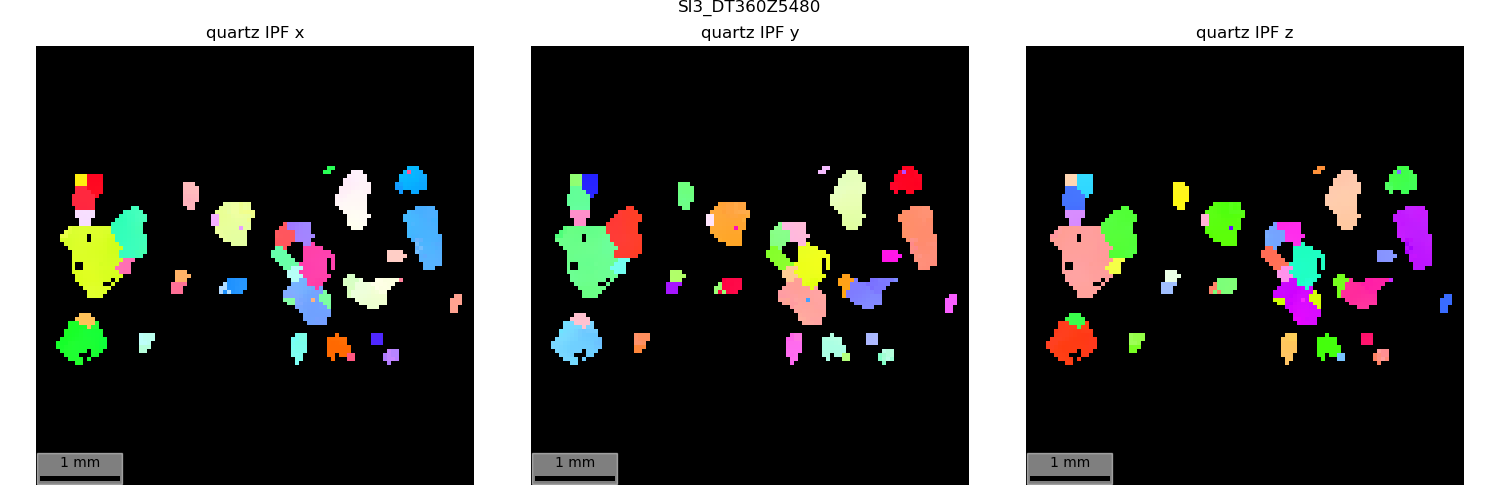

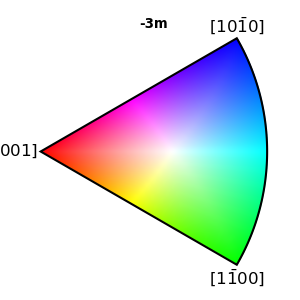

In [140]:
save=False

xmap.plot_ipf_orientation(pname, ipf_directions='xyz', smooth=False, smooth_kernel_size=3)


We can also plot other outputs:

In [123]:
xmap.titles()

['xyi',
 'xi',
 'yi',
 'phase_id',
 'grain_id',
 'Npks',
 'completeness',
 'phase_label_confidence',
 'uniqueness',
 'nindx',
 'drlv2',
 'indx_completeness',
 'U',
 'UBI',
 'unitcell']

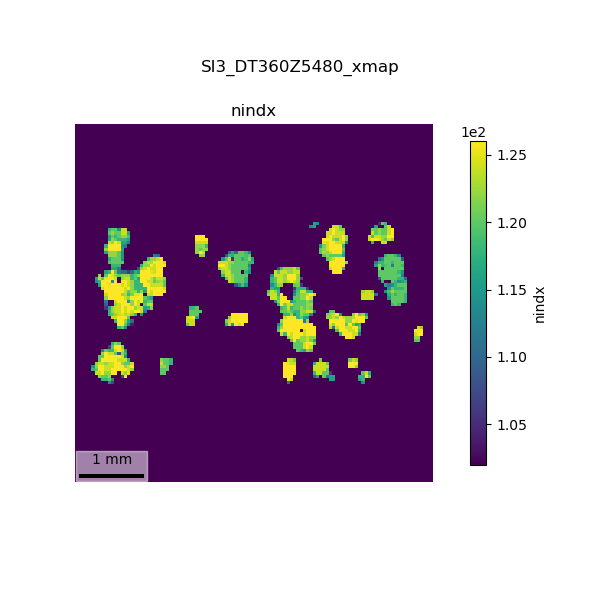

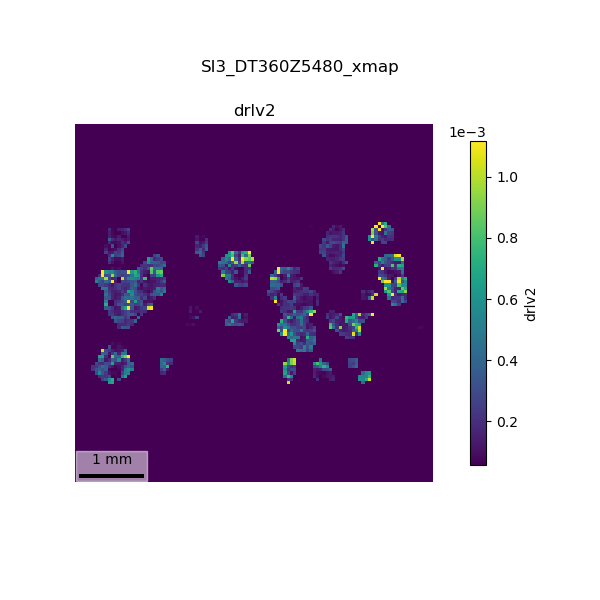

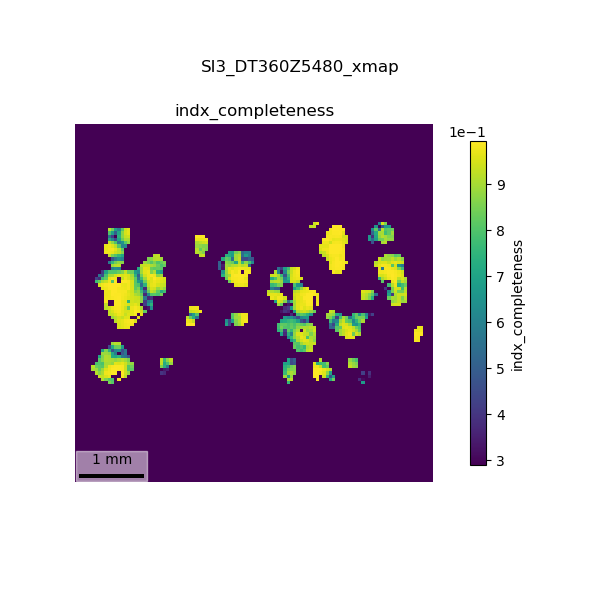

In [141]:
save=False
var_to_plot = ['nindx','drlv2', 'indx_completeness']
kw = {'cmap':'viridis'}

for var in var_to_plot:
    xmap.plot(var, autoscale=True, smooth=True, mf_size=1, save=save, **kw)


### Noisy orientations investigation
In case the orientation map looks noisy, you may want to know whats going on with badly indexed pixels. It can be useful to look at g-vectors and how they are indexed
- select two pixels (one correctly oriented, one noisy orientation)
- run indexing on both with loginfo=True, to print info on ubis found and indexing scores

Typical issues:
- too few / bad g-vectors on noisy pixels -> try to increase kernel size to get more g-vectors from neighbors 
- maxpks or nrings too low: miss the "correct" orientation -> increase sliughtly these parameters until the correct orientation is found

In [ ]:
# select list of pixels to investigate. xyi index value: xyi = 1000.yi + xi  (e.g. (xi,yi) = (34,23) -> xyi = 230034
px1 = 780021
px2 = 680033


# plot them on the map to see where they are
kw = {'cmap':'viridis'}
fig = xmap.plot('nindx', out=True,**kw)
for px in [px1,px2]:
    fig.axes[0].scatter(px%10000,px//10000, s=30, marker='*')
fig.axes[0].set_axis_on()
    

In [ ]:
#plot pole figures of g-vectors (aligned with crystallographic c-axis pointing upward)-> check if they correspond to a unique grain

import orix.quaternion as oq
import orix.vector as ovec

def get_gvecs(cf, px, kernel_size=1):
    # for pixels. px: index xyi = 1000*yi+xi
    s = peak_mapping.pks_from_px(cf.xyi, px, kernel_size=kernel_size)
    gv = np.array( (cf.gx[s],cf.gy[s],cf.gz[s])).T.copy()
    ints = cf.norm_intensity[s]
    return gv, ints, s

def plot_gvectors_polefig(cf, px, kernel_size=1, sf=1, **subplot_kw):
    fig = pl.figure(figsize=(5,5), layout='constrained')
    fig.suptitle(f'clustered g-vectors', fontsize=14, fontweight="bold")

    ax = fig.add_subplot(111, **subplot_kw)
    ax.set_axis_off()
    U = xmap.U[xmap.xyi == px]
    gv, ints, sel = get_gvecs(cf, px, kernel_size)
    R = oq.Rotation.from_matrix(U)  # realign g-vectors to have c-axis pointing upward
    
    V= ovec.Vector3d(gv).rotate(R.axis, -R.angle)
    ax.scatter(V, c=pow(ints,1/3), s=sf*pow(ints,1/3), vmin=1,vmax=6)
    ax.set_title(f'x={px%10000:d}, y={px//10000:d}')


In [ ]:
# print g-vector number and toital intensity per pixel selected
for px in [px1,px2]:
    gv, ints, s = get_gvecs(cf, px, kernel_size=1)
    print(len(ints), ints.sum())

In [ ]:
# plot g-vector pole figure
subplot_kw ={'projection':'stereographic','hemisphere':'upper'}
for px in [px1, px2]:
    plot_gvectors_polefig(cf, px, kernel_size=9, sf=1, **subplot_kw)

In [ ]:
# index each pixel with loginfo option, to see how ubi scores look like

with local_indexing.indexing_context(parfile, cs):
    for px in [px1, px2]:
        args = (px, OPTS)
        print(f'px : {px}')
        res = local_indexing.pixel_ubi_fit(args, loginfo=True)
        print(f'results: {res}')
        print(f'\n========================\n')

In [ ]:
# update OPTS and re-index
OPTS.px_kernel_size = 1
OPTS.nrings = 12
OPTS.max_mult = 12
print(OPTS)

### Save pixelmap

Once you are satisfied with indexing outputs, save the results in a json file. If the map has been fully indexed, you can save it as well. Nothing has been added to the peakfile, so no need to save cf.

For multi-phase indexing, you have to re-do all the steps in this notebook to find the set of indexing parameters that works the best for each phase. For sample `SI3`, you can try with oligoclase (triclinic) and orthoclase (monoclinic). For `C18A_01`, try with garnet (cubic). 

In [ ]:
OPTS.save(os.path.join(data_dir,f"indexing_pars_{pname}.json"))

In [142]:
xmap.save_to_hdf5()

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap.h5
